In [30]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors

from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

from scipy.stats import ttest_ind

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## Fully Coupled Model Experiments
### (FCM_Pi.DustMio - FCM_Pi.DustPi): Miocene dust impacts on PI climate 
### (FCM_Mio.DustMio - FCM_Mio.DustPi): Miocene dust impacts on Miocene climate 

#### (1) Surface Temperatura & net TOA radiation

In [31]:
ds = xr.open_dataset('./Fig5a_FCM_TS_TOA.nc')

# read surface temperature data

ts_Pi_ano = ds['ts_Pi_ano']
ts_Mio_ano = ds['ts_Mio_ano']

# read net TOA radiation data

toa_Pi_ano = ds['toa_Pi_ano']
toa_Pi_ano_yr = ds['toa_Pi_ano_annual']
toa_Mio_ano = ds['toa_Mio_ano']
toa_Mio_ano_yr = ds['toa_Mio_ano_annual']

In [29]:
# surface temperature: polar amplification index

ts_Pi_ano_gmean = ts_Pi_ano.weighted(weights).mean(dim=['lon','lat']) 
ts_Mio_ano_gmean = ts_Mio_ano.weighted(weights).mean(dim=['lon','lat']) 

ts_Pi_ano_NH = ts_Pi_ano[79:96,:].weighted(weights).mean(dim=['lon','lat']) 
ts_Pi_ano_SH = ts_Pi_ano[0:17,:].weighted(weights).mean(dim=['lon','lat']) 

ts_Mio_ano_NH = ts_Mio_ano[79:96,:].weighted(weights).mean(dim=['lon','lat']) 
ts_Mio_ano_SH = ts_Mio_ano[0:17,:].weighted(weights).mean(dim=['lon','lat']) 

ts_Pi_ano_NH_pa = ts_Pi_ano_NH/ts_Pi_ano_gmean
ts_Pi_ano_SH_pa = ts_Pi_ano_SH/ts_Pi_ano_gmean
ts_Mio_ano_NH_pa = ts_Mio_ano_NH/ts_Pi_ano_gmean
ts_Mio_ano_SH_pa = ts_Mio_ano_SH/ts_Pi_ano_gmean

print('{:03.2f}'.format(ts_Pi_ano_gmean.values))
print('{:03.2f}'.format(ts_Mio_ano_gmean.values))
print('{:03.2f}'.format(ts_Pi_ano_NH_pa.values))
print('{:03.2f}'.format(ts_Pi_ano_SH_pa.values))
print('{:03.2f}'.format(ts_Mio_ano_NH_pa.values))
print('{:03.2f}'.format(ts_Mio_ano_SH_pa.values))

0.24
0.16
4.43
3.08
0.43
2.11


In [23]:
# net TOA radiation: standard deviation (annual means of year 401-500)

toa_Pi_ano_gmean = toa_Pi_ano.weighted(weights).mean(dim=['lon','lat']) 
toa_Mio_ano_gmean = toa_Mio_ano.weighted(weights).mean(dim=['lon','lat']) 
toa_Pi_ano_yr_std = toa_Pi_ano_yr.std(dim=['year']) 
toa_Mio_ano_yr_std = toa_Mio_ano_yr.std(dim=['year']) 

print('{:03.2f}'.format(toa_Pi_ano_gmean.values))
print('{:03.2f}'.format(toa_Mio_ano_gmean.values))
print('{:03.2f}'.format(toa_Pi_ano_yr_std.values))
print('{:03.2f}'.format(toa_Mio_ano_yr_std.values))

0.07
0.01
0.57
0.38


In [27]:
pattern_mean = np.empty((4, lat.size, lon.size))
pattern_mean = xr.DataArray(data=pattern_mean, dims=['pattern','lat','lon'], coords=[np.arange(1,4.5,1), lat, lon])

pattern_mean[0,:,:] = ts_Pi_ano
pattern_mean[1,:,:] = ts_Mio_ano
pattern_mean[2,:,:] = toa_Pi_ano
pattern_mean[3,:,:] = toa_Mio_ano

# Add cyclic point to data
data = pattern_mean
data, lons = add_cyclic_point(data, coord=lon)

''

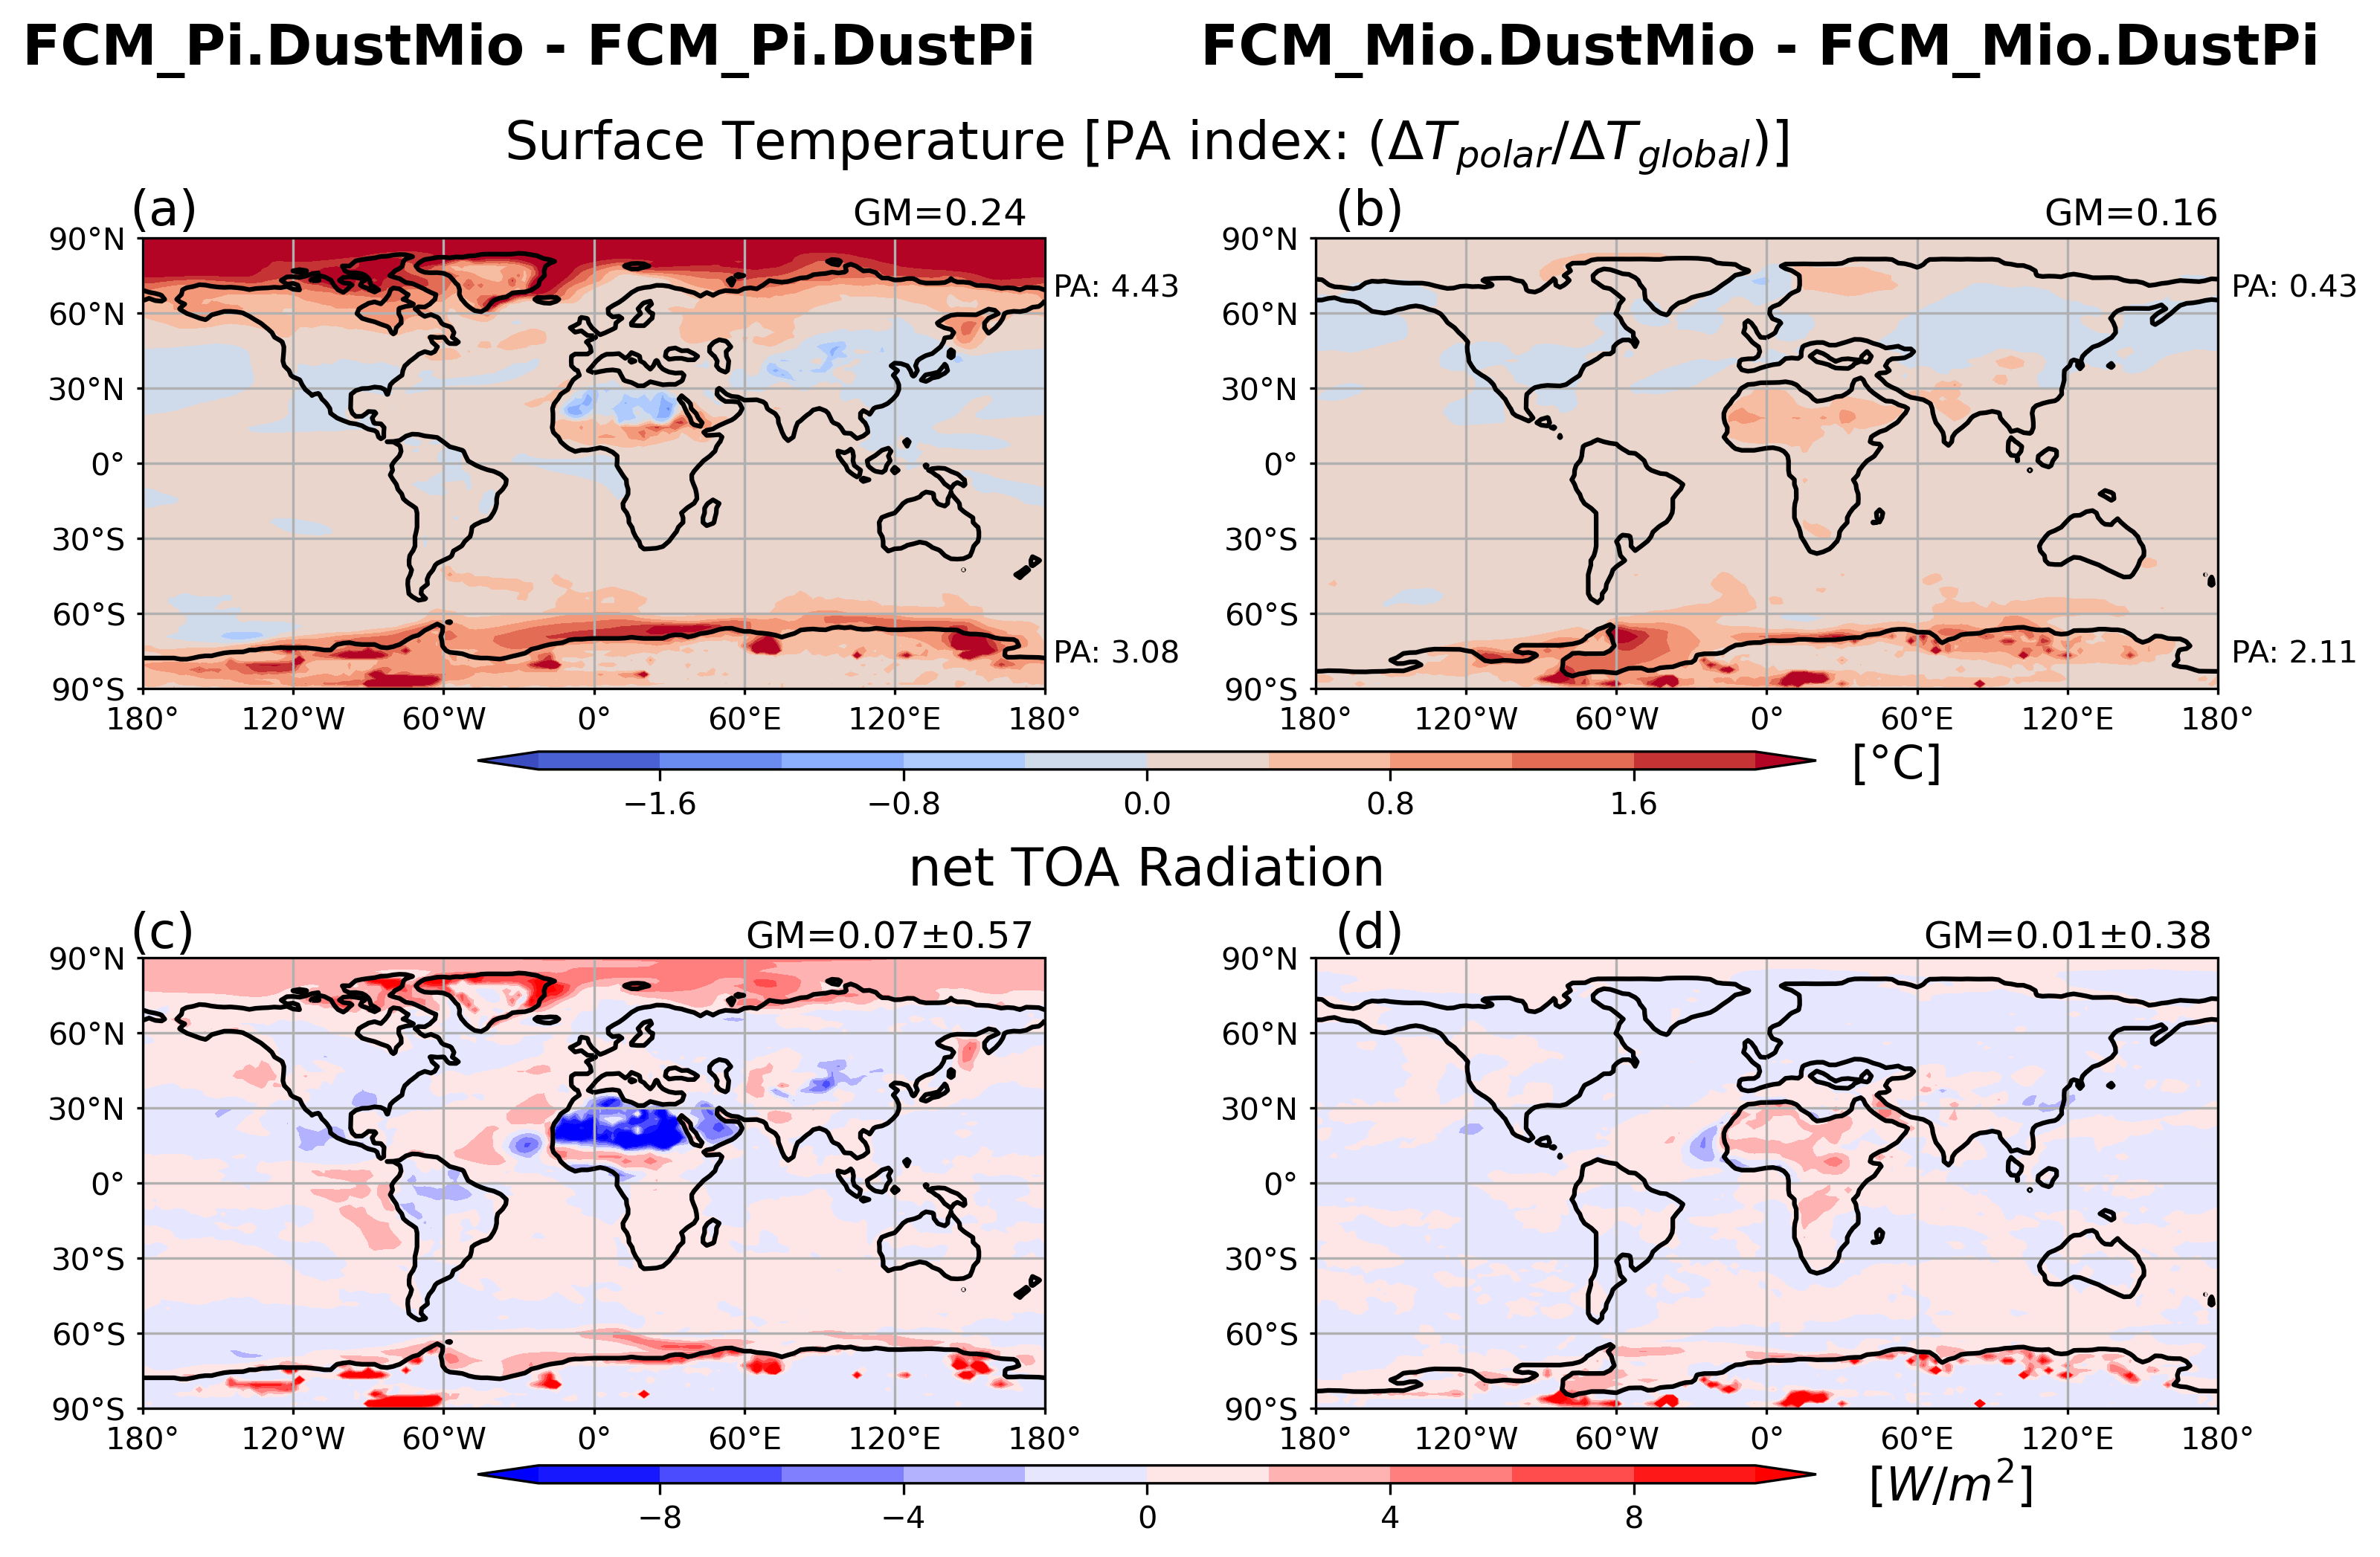

In [28]:
# --- plot ---

# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(12,8), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.3, hspace=0.1) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(pattern_mean['pattern']):
        
    # Contour plot
    # Add coastines in Miocene Scenario
    if i==0:
        cs1=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-2, 2, 11),
                            transform = ccrs.PlateCarree(), cmap='coolwarm', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    
    elif i==1:
        cs1=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-2, 2, 11),
                            transform = ccrs.PlateCarree(), cmap='coolwarm', extend='both')
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    
    elif i==2:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-10, 10, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    
    else:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-10, 10, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    
    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='x', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(10)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(10)        
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax1 = fig.add_axes([0.25, 0.525, 0.5, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB1  = plt.colorbar(cs1, cax=cax1, orientation='horizontal')
cax2 = fig.add_axes([0.25, 0.125, 0.5, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')

# Add colobar's title
GM_Pi = 'GM='+str('{:03.2f}'.format(ts_Pi_ano_gmean.values))
GM_Mio = 'GM='+str('{:03.2f}'.format(ts_Mio_ano_gmean.values))
GM_toa_Pi = 'GM='+str('{:03.2f}'.format(toa_Pi_ano_gmean.values))+'±'+str('{:03.2f}'.format(toa_Pi_ano_yr_std.values))
GM_toa_Mio = 'GM='+str('{:03.2f}'.format(toa_Mio_ano_gmean.values))+'±'+str('{:03.2f}'.format(toa_Mio_ano_yr_std.values))

PA_Pi_NH = 'PA: '+str('{:03.2f}'.format(ts_Pi_ano_NH_pa.values))
PA_Pi_SH = 'PA: '+str('{:03.2f}'.format(ts_Pi_ano_SH_pa.values))
PA_Mio_NH = 'PA: '+str('{:03.2f}'.format(ts_Mio_ano_NH_pa.values))
PA_Mio_SH = 'PA: '+str('{:03.2f}'.format(ts_Mio_ano_SH_pa.values))


plt.figtext(0.78,0.52,'[°C]',ha='center',fontsize=15)
plt.figtext(0.12,0.83,'(a)',fontsize=16)
plt.figtext(0.08,0.92,'FCM_Pi.DustMio - FCM_Pi.DustPi',fontsize=18, weight='bold')
plt.figtext(0.39,0.83,GM_Pi,fontsize=12)
plt.figtext(0.57,0.83,'(b)',fontsize=16)
plt.figtext(0.52,0.92,'FCM_Mio.DustMio - FCM_Mio.DustPi',fontsize=18, weight='bold')
plt.figtext(0.835,0.83,GM_Mio,fontsize=12)

plt.figtext(0.465,0.79,PA_Pi_NH,fontsize=10)
plt.figtext(0.465,0.585,PA_Pi_SH,fontsize=10)
plt.figtext(0.905,0.79,PA_Mio_NH,fontsize=10)
plt.figtext(0.905,0.585,PA_Mio_SH,fontsize=10)

plt.figtext(0.8,0.115,'$[W/m^2]$',ha='center',fontsize=15)
plt.figtext(0.12,0.425,'(c)',fontsize=16)
plt.figtext(0.35,0.425,GM_toa_Pi,fontsize=12)
plt.figtext(0.57,0.425,'(d)',fontsize=16)
plt.figtext(0.79,0.425,GM_toa_Mio,fontsize=12)
plt.figtext(0.5,0.46,'net TOA Radiation',ha='center',fontsize=17)

# Add title
plt.suptitle('Surface Temperature [PA index: ($ΔT_{polar} / ΔT_{global}$)]', y=0.89, fontsize=17)
# plt.suptitle('Surface Temperature', y=0.685, fontsize=18)
# fig.savefig('plot_net_radiation_TOA.png')
;

#### (2) ICE Fraction

In [32]:
# Function of Plotting --- time-series                                                                            

def time_series(data, xlabel, xticks, xticklabels, ylabel,
                xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title):

    # --- Create the plot - index2 ---
    fig, ax1 = plt.subplots(dpi=300)
    fig.set_size_inches(4,2)
    
    ax1.set_xlabel(xlabel)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticklabels, fontsize=8)
    ax1.set_ylabel(ylabel)
    yticklabels = np.arange(ymin,ymax+1,5)
    ax1.set_yticklabels(yticklabels, fontsize=8)
    
    for i,m in enumerate(legend): 
        ax1.plot(xrange[i,:], data[i,:], color=colors[i])

    plt.title(title, fontsize=10)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend(legend)
    # plt.axhline(y = 0.0, color = 'k', linestyle = '-') 
    
    plt.plot([-1,2000], yRef, "k--")
    plt.plot([2000,2000], [-100,100], "k--")

    # Show the plot
    plt.show()

/glade/derecho/scratch/pjchen/tmp/ipykernel_26931/1143513037.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(yticklabels, fontsize=8)


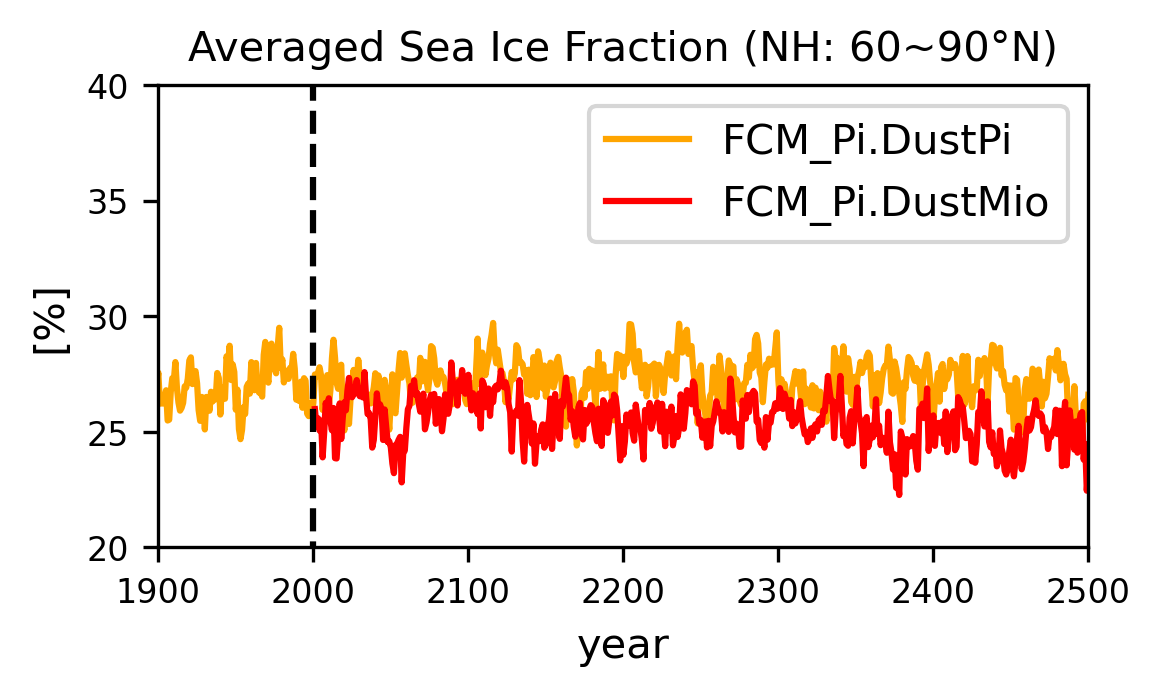

In [35]:
ds_Pi_ice = xr.open_dataset('./Fig5b_FCM_Pi_ICEFRAC.nc')

# read ice fraction (PI Experiments) at North Pole

ice_Pi = ds_Pi_ice['ice_Pi_NH']


# plot ICE fraction evolution
xrange = np.empty((2, ice_Pi[0,:].size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,ice_Pi[0,:].size+1,1)
xrange[1,:] = np.arange(1,ice_Pi[0,:].size+1,1)

xlabel = 'year'
xticks = np.arange(0,ice_Pi[0,:].size+1,100)
xticklabels = np.arange(0,ice_Pi[0,:].size+1,100)
ylabel = '[%]'
xmin = 1900
xmax = 2500
ymin = 20
ymax = 40
legend = ['FCM_Pi.DustPi','FCM_Pi.DustMio']
colors = ['orange','r']
title = 'Averaged Sea Ice Fraction (NH: 60~90°N)'

yRef = [-1,-1]

time_series(ice_Pi, xlabel, xticks, xticklabels, ylabel, 
            xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)

/glade/derecho/scratch/pjchen/tmp/ipykernel_26931/1143513037.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(yticklabels, fontsize=8)


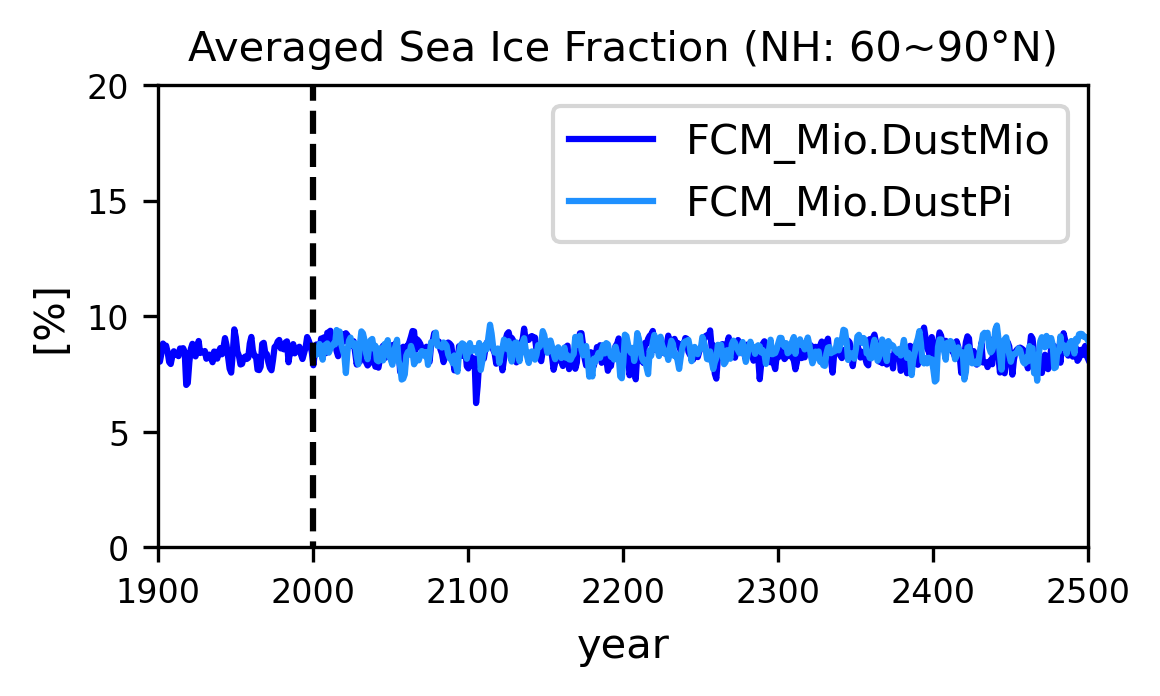

In [37]:
ds_Mio_ice = xr.open_dataset('./Fig5c_FCM_Mio_ICEFRAC.nc')

# read ice fraction (Mio Experiments) at North Pole

ice_Mio = ds_Mio_ice['ice_Mio_NH']


# plot ICE fraction evolution
xrange = np.empty((2, ice_Mio[0,:].size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,ice_Mio[0,:].size+1,1)
xrange[1,:] = np.arange(1,ice_Mio[0,:].size+1,1)

xlabel = 'year'
xticks = np.arange(0,ice_Mio[0,:].size+1,100)
xticklabels = np.arange(0,ice_Mio[0,:].size+1,100)
ylabel = '[%]'
xmin = 1900
xmax = 2500
ymin = 0
ymax = 20
legend = ['FCM_Mio.DustMio','FCM_Mio.DustPi']
colors = ['b','dodgerblue']
title = 'Averaged Sea Ice Fraction (NH: 60~90°N)'

yRef = [-1,-1]

time_series(ice_Mio, xlabel, xticks, xticklabels, ylabel, 
            xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)